## Manipulation of hysteresis loops

This tutorial will provide a few examples for automated data correction/manipulation of (magnetic) hysteresis loops possible with evaluix.
First, read in some simulated data, here based on a Stoner Wohlfahrt Approach in combination with a unidirectional anisotropy (exchange bias)

In [93]:
from pathlib import Path
import pandas as pd

csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop_with_outliers.csv"
data = pd.read_csv(csv_path)

data.head()

,Applied Field (H [arb. u.]),Magnetization with slope
0,200.0,4.102451
1,199.0,4.186659
2,198.0,4.175292
3,197.0,4.200445
4,196.0,4.191541


As you can see below, the hysteresis loop has an exchange bias shift of ca. -60 resulting in a loop shifted from the ordinate (x=0). Special attention should be drawn to the outliers, especially in saturation

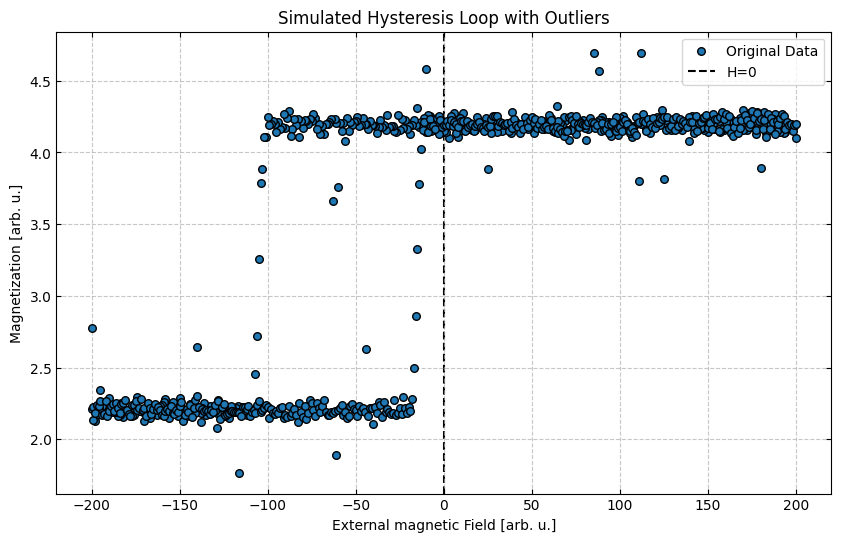

In [94]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], label='Original Data', edgecolor='k', s=30, zorder=5)
plt.title('Simulated Hysteresis Loop with Outliers')
plt.xlabel('External magnetic Field [arb. u.]')
plt.ylabel('Magnetization [arb. u.]')
plt.tick_params(direction='in', top=True, right=True)
plt.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
plt.axvline(0, color='k', linestyle='--', label='H=0', zorder=1)
plt.legend()
plt.show()

Evaluix magically finds these outliers and replaces them by then mean of their direct neighbours (based on index, NOT on field)

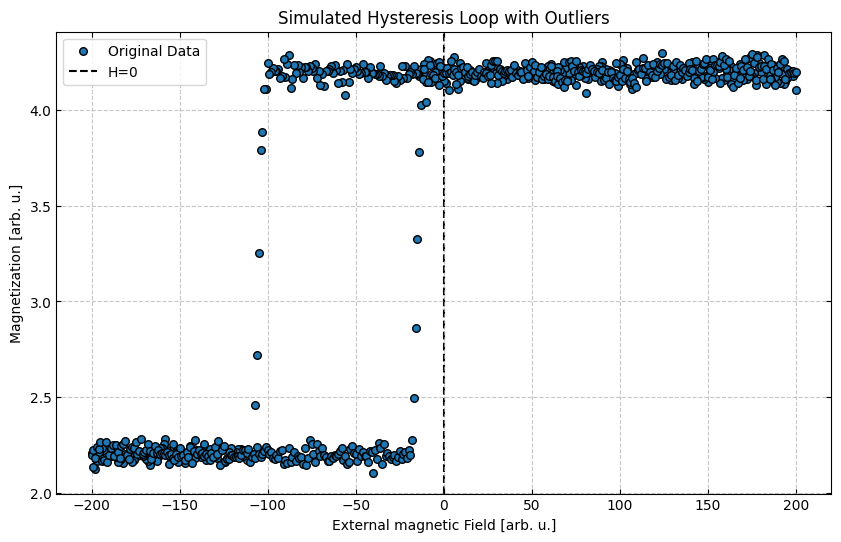

In [95]:
from evaluix.utils import HysteresisFunctions as hf

data.iloc[:, 1] = hf.del_outliers(data.iloc[:, 1])

plt.figure(figsize=(10, 6))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], label='Original Data', edgecolor='k', s=30, zorder=5)
plt.title('Simulated Hysteresis Loop with Outliers')
plt.xlabel('External magnetic Field [arb. u.]')
plt.ylabel('Magnetization [arb. u.]')
plt.tick_params(direction='in', top=True, right=True)
plt.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
plt.axvline(0, color='k', linestyle='--', label='H=0', zorder=1)
plt.legend()
plt.show()